# Testing Tetris with Reinforcement Learning with Sensorial Input (DQN-CNN algo)

## C

### Imports

In [1]:
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation
from gymnasium.wrappers import ResizeObservation
from gymnasium.wrappers import GrayscaleObservation
from gymnasium.wrappers import ResizeObservation
from gymnasium.wrappers import TransformObservation
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo

import matplotlib
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np

from collections import namedtuple, deque
from itertools import count
import random
import math
from tetris_env import TetrisEnv
from a_helper import plot_all
from a_helper import save_dqn_model

### NotebookDisplay and Device

In [2]:
# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(device)

cuda


## Model

In [3]:
class DQN(nn.Module):
    def __init__(self, in_channels,n_actions):
        super().__init__()
        self.conv_linear_relu_stack = nn.Sequential(
            nn.Conv2d(in_channels, 16, (8,8), stride=4),
            nn.ReLU(),
            nn.Conv2d(16, 32, (4,4),stride=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(2592,256),
            nn.ReLU(),
            nn.Linear(256,n_actions)
        )

    def forward(self, x):
        logits = self.conv_linear_relu_stack(x)
        return logits

### ReplayMemory

In [4]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))


class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

### Action

In [5]:
def get_action(state, epsilon, test=False):
    sample = random.random()
    if sample > epsilon or test:
        with torch.no_grad():
            # Toma el indice de la accion con mayor y ajusta la forma del tensor
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        # Escoge una accion aleatoria
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

## Init

In [6]:
training_period = 250 # Cada cuento graba un video
algo_id = "dqn_cnn_pytorch"
start_episode = 0

In [7]:
base_env = TetrisEnv(board_width=10,
                board_height=22,
                time_limit_s=120,
                obs_type="rgb_array",
                render_mode='human')

env = TransformObservation(base_env, lambda obs: obs[:, 0:300], observation_space=base_env.observation_space)
env = GrayscaleObservation(env)
env = ResizeObservation(env, (84, 84))
env = FrameStackObservation(env, 4)
env = TransformObservation(env, lambda obs: obs / 255.0, observation_space=base_env.observation_space)
n_actions = base_env.action_space.n

steps_done = 0

Using Default internal config


## Loading model

In [9]:
filename = "dqn_cnn_pytorch_9.pth"
checkpoint_path=f"models/{filename}"

# Cargamos el modelo
if os.path.exists(checkpoint_path):
    policy_net = DQN(in_channels=4, n_actions=n_actions).to(device)
    
    
    checkpoint = torch.load(checkpoint_path, weights_only=False,map_location=device)
    start_episode = checkpoint['episode'] + 1
    policy_net.load_state_dict(checkpoint['policy_net'])
    env.internal_config = checkpoint['env_internal_config']
    
    metadata = checkpoint['metadata']
    memory = checkpoint['memory']
    
    print(f"Loaded checkpoint from episode {start_episode}")
    print(metadata)
    policy_net.eval()
else:
    raise Exception("Checkpoint Not Found")

Loaded checkpoint from episode 10
{'algorithm': 'DQN from PyTorch Tutorial, CNN from Atari Paper', 'note': 'Como observacion de la queue solo tiene la siguiente pieza, no las 5 siguientes', 'hyper': {'BATCH_SIZE': 32, 'GAMMA': 0.99, 'EPS_START': 1, 'EPS_END': 0.1, 'EPS_DECAY': 6e-07, 'EPS_DECAY_STRAT': 'Subtract after every step', 'TAU': 0.001, 'LR': 0.0001}}


## Main Test

episode 10
-858.0473333333334


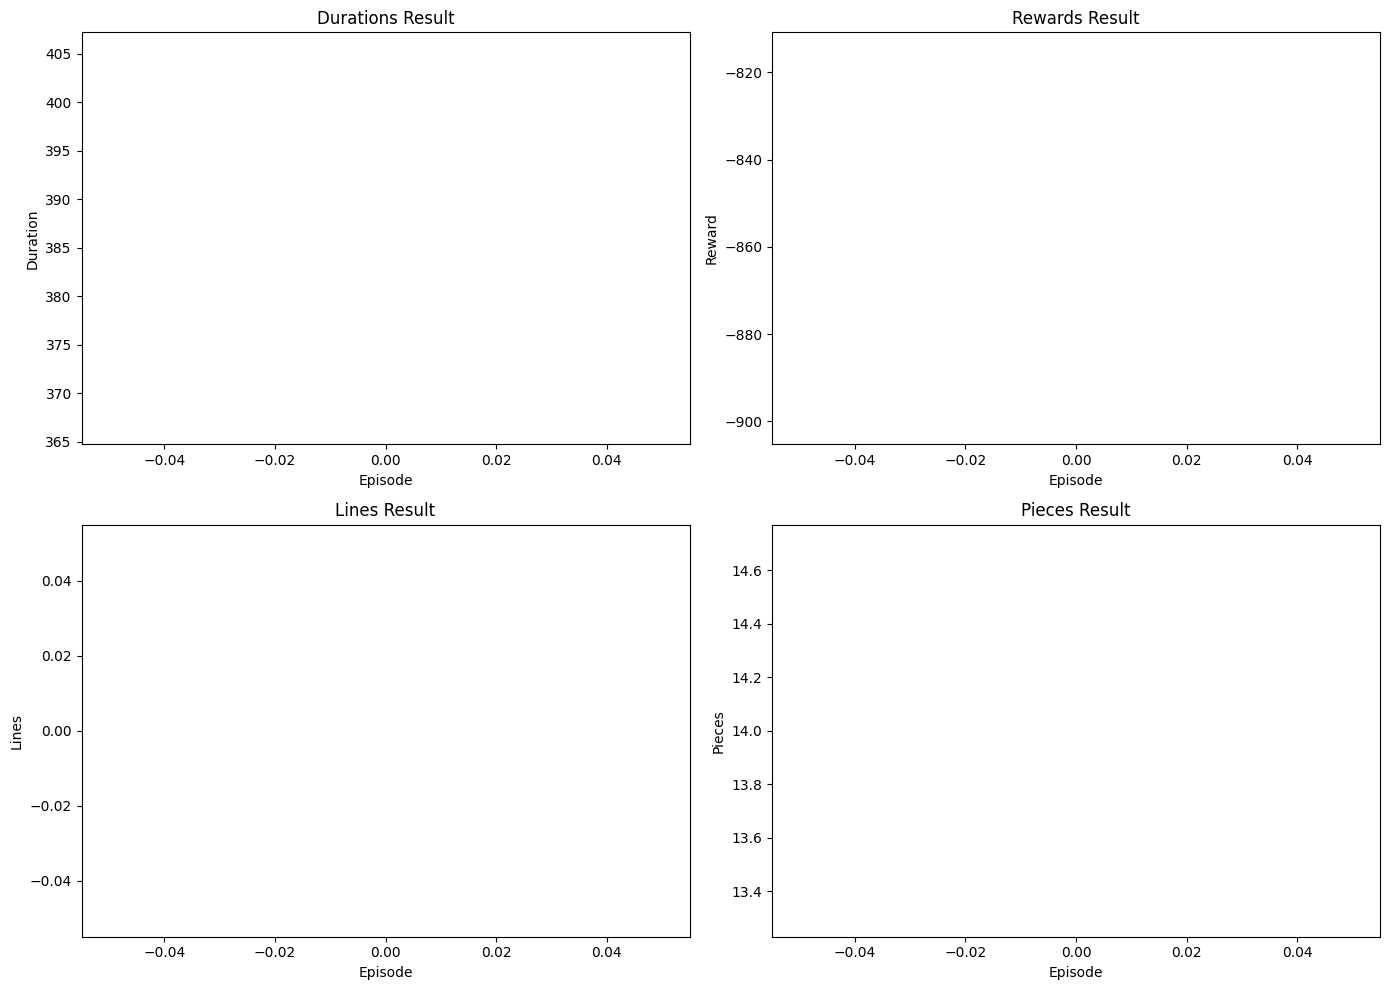

Duration: 386.0
Reward: -858.0473333333334
Lines: 0.0
Pieces: 14.0
Complete


In [10]:
total_episodes = 1

episode_lines = []
episode_durations = []
episode_rewards = []
episode_pieces = []

for i_episode in range(total_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0
    done = False
    
    for t in count():
        action = get_action(state,0,test=True)
        next_state, reward, terminated, truncated, info = env.step(action.item())
        
        reward = torch.tensor([reward], device=device)
        total_reward += reward.item()
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(next_state, dtype=torch.float32, device=device).unsqueeze(0)

        state = next_state
        
        if done:
            episode_durations.append(t + 1)
            episode_rewards.append(total_reward)
            episode_lines.append(info['lines_cleared'])
            episode_pieces.append(info['pieces_placed'])
            plot_all(episode_durations,episode_rewards,episode_lines,episode_pieces)
            print("episode",i_episode+start_episode)
            print(total_reward)
            break
        
plot_all(episode_durations,episode_rewards,episode_lines,episode_pieces,save=True,show_result=True,filename=f"plots/temp.png")
print("Duration:", np.mean(episode_durations))
print("Reward:", np.mean(episode_rewards))
print("Lines:", np.mean(episode_lines))
print("Pieces:", np.mean(episode_pieces))
plt.ioff()
plt.show()
env.close()
print('Complete')